In [1]:
!pip install requests pandas matplotlib fpdf --quiet

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from fpdf import FPDF
from datetime import datetime
import time

In [4]:
# Unos više URL-ova u terminalu ili Jupyter-u
urls_input = input("Unesite web sajtove odvojene zarezom:\n")
urls = [url.strip() for url in urls_input.split(",") if url.strip() != ""]

print(f"\nProveriće se sledeći sajtovi:\n{urls}")

Unesite web sajtove odvojene zarezom:
 https://google.com, https://github.com, https://python.org, https://notrealwebsite12345.com



Proveriće se sledeći sajtovi:
['https://google.com', 'https://github.com', 'https://python.org', 'https://notrealwebsite12345.com']


In [5]:
def check_website(url, timeout=5):
    """
    Proverava status web sajta i meri vreme odziva.
    Vraća dict sa URL, status, response_time i porukom.
    """
    result = {"URL": url, "Status Code": None, "Response Time (s)": None, "Status": None}
    try:
        start = time.time()
        response = requests.get(url, timeout=timeout)
        end = time.time()
        
        result["Status Code"] = response.status_code
        result["Response Time (s)"] = round(end - start, 3)
        
        # Klasifikacija statusa
        if response.status_code == 200:
            result["Status"] = "UP"
        elif response.status_code == 404:
            result["Status"] = "NOT FOUND"
        elif response.status_code >= 500:
            result["Status"] = "SERVER ERROR"
        else:
            result["Status"] = "UNKNOWN"
    except requests.exceptions.Timeout:
        result["Status"] = "DOWN (Timeout)"
    except requests.exceptions.RequestException:
        result["Status"] = "DOWN (Error)"
    
    return result

In [6]:
results = []

for url in urls:
    res = check_website(url)
    results.append(res)
    print(f"{res['URL']}: {res['Status']} ({res['Status Code']}) - {res['Response Time (s)']}s")

# Kreiranje DataFrame-a
df_results = pd.DataFrame(results)
df_results

https://google.com: UP (200) - 1.151s
https://github.com: UP (200) - 0.226s
https://python.org: UP (200) - 0.264s
https://notrealwebsite12345.com: DOWN (Error) (None) - Nones


,URL,Status Code,Response Time (s),Status
0,https://google.com,200.0,1.151,UP
1,https://github.com,200.0,0.226,UP
2,https://python.org,200.0,0.264,UP
3,https://notrealwebsite12345.com,NaN,NaN,DOWN (Error)


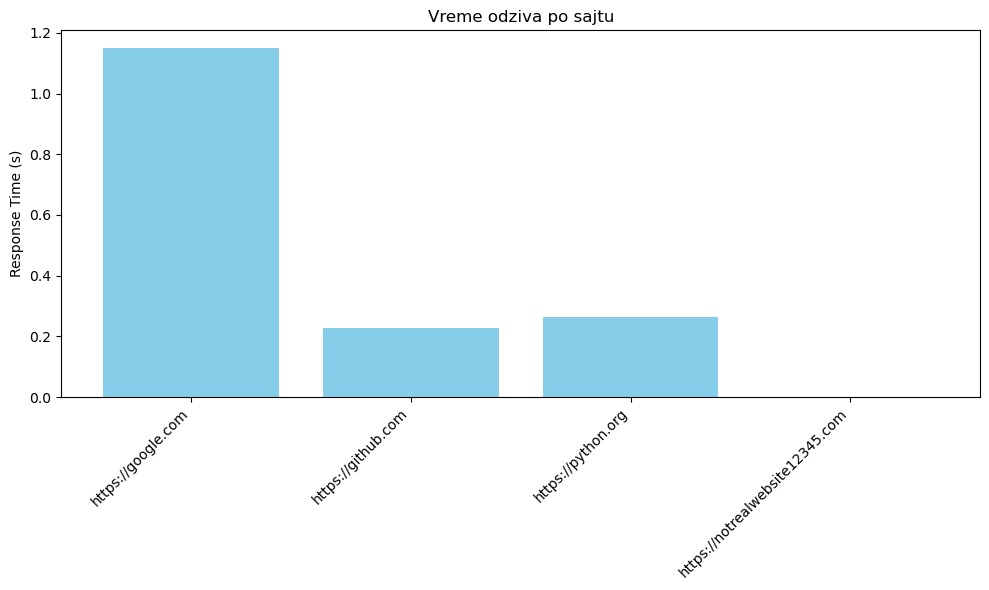

In [17]:
plt.figure(figsize=(10,6))
plt.bar(df_results['URL'], df_results['Response Time (s)'].fillna(0), color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Response Time (s)')
plt.title('Vreme odziva po sajtu')
plt.tight_layout()
plt.show()
#da stavi crveno ako ne ucita sajt

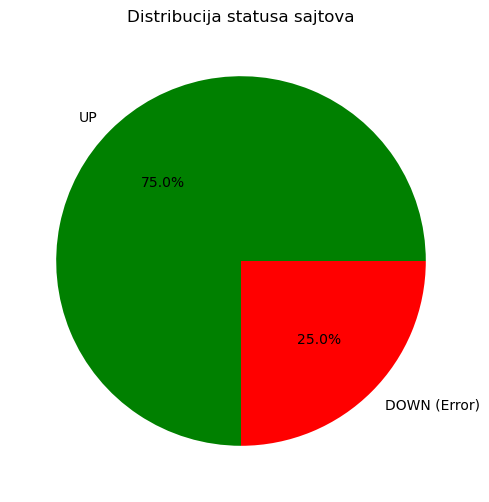

In [8]:
status_counts = df_results['Status'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=['green','red','orange','gray'])
plt.title('Distribucija statusa sajtova')
plt.show()

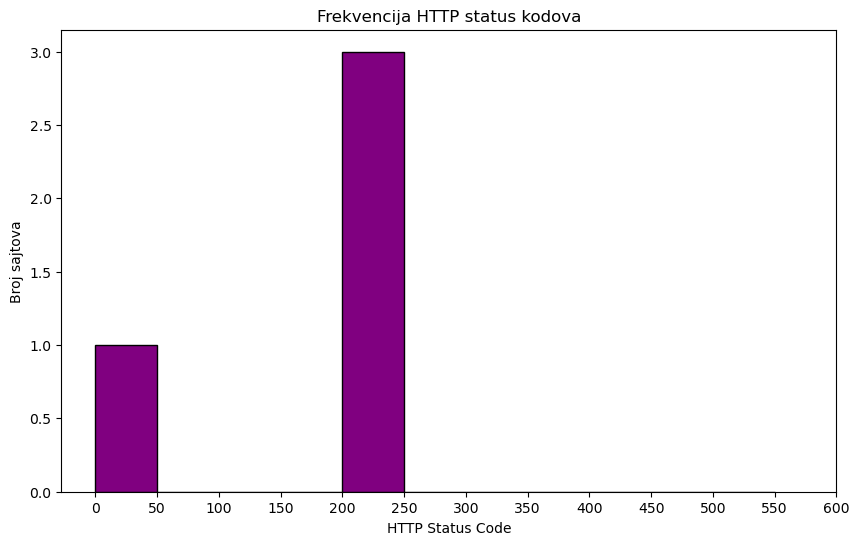

In [12]:
plt.figure(figsize=(10,6))
status_codes = df_results['Status Code'].fillna(0)

plt.hist(status_codes, bins=range(0, 600, 50), color='purple', edgecolor='black')
plt.xlabel('HTTP Status Code')
plt.ylabel('Broj sajtova')
plt.title('Frekvencija HTTP status kodova')
plt.xticks(range(0, 601, 50))
plt.show()

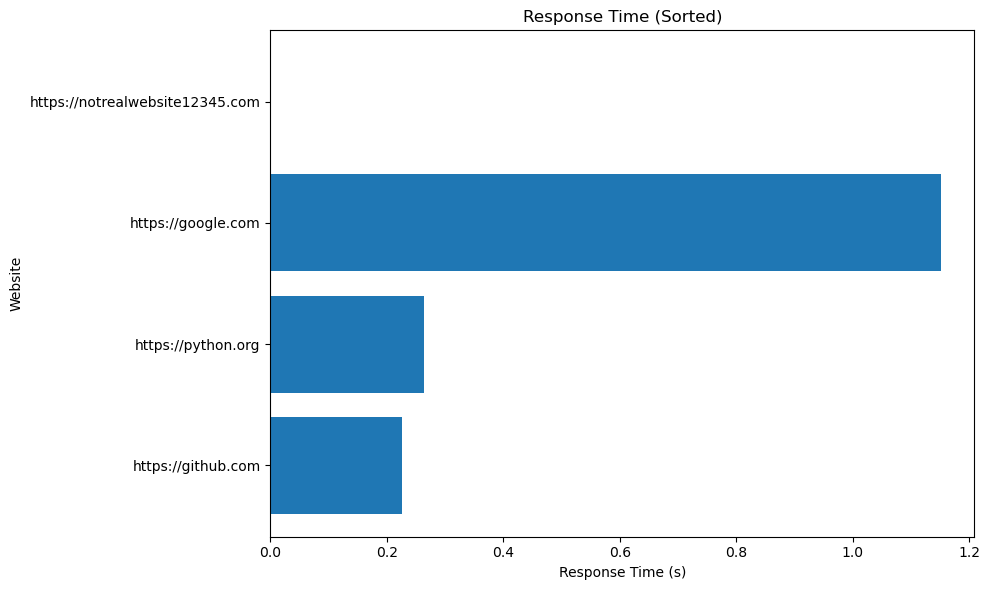

In [13]:
plt.figure(figsize=(10,6))

df_sorted = df_results.sort_values(by='Response Time (s)', ascending=True)

plt.barh(df_sorted['URL'], df_sorted['Response Time (s)'].fillna(0))
plt.xlabel('Response Time (s)')
plt.ylabel('Website')
plt.title('Response Time (Sorted)')
plt.tight_layout()

plt.show()

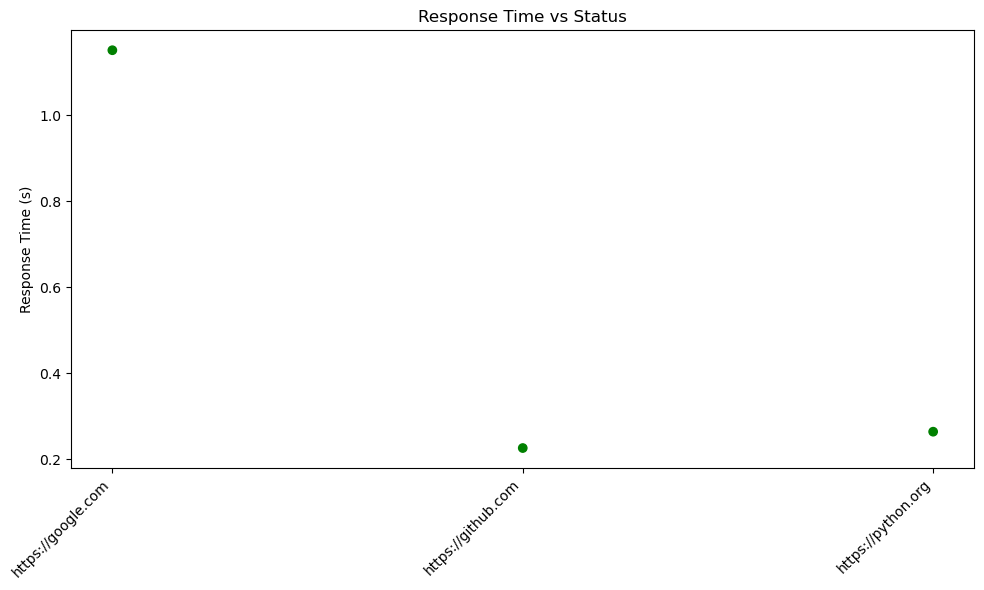

In [15]:
plt.figure(figsize=(10,6))

colors = df_results['Status'].apply(lambda x: 'green' if x == 'UP' else 'red')

plt.scatter(df_results['URL'], df_results['Response Time (s)'], c=colors)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Response Time (s)')
plt.title('Response Time vs Status')

plt.tight_layout()
plt.show()

In [ ]:
def generate_pdf(df, filename="report.pdf"):
    pdf = FPDF()
    pdf.set_auto_page_break(auto=True, margin=15)
    pdf.add_page()
    pdf.set_font("Arial", "B", 16)
    
    # Naslov i datum
    pdf.cell(0, 10, "Website Status Report", ln=True, align='C')
    pdf.set_font("Arial", "", 12)
    pdf.cell(0, 10, f"Date & Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", ln=True, align='C')
    pdf.ln(10)
    
    # Rezultati tabela
    pdf.set_font("Arial", "B", 12)
    col_width = pdf.w / 4.5
    pdf.cell(col_width, 10, "URL", 1)
    pdf.cell(col_width, 10, "Status Code", 1)
    pdf.cell(col_width, 10, "Response Time", 1)
    pdf.cell(col_width, 10, "Status", 1)
    pdf.ln()
    
    pdf.set_font("Arial", "", 12)
    for index, row in df.iterrows():
        pdf.cell(col_width, 10, str(row['URL']), 1)
        pdf.cell(col_width, 10, str(row['Status Code']), 1)
        pdf.cell(col_width, 10, str(row['Response Time (s)']), 1)
        pdf.cell(col_width, 10, str(row['Status']), 1)
        pdf.ln()
    
    # Statistika
    pdf.ln(5)
    pdf.set_font("Arial", "B", 12)
    pdf.cell(0, 10, "Summary:", ln=True)
    pdf.set_font("Arial", "", 12)
    total = len(df)
    up = len(df[df['Status'] == 'UP'])
    down = len(df[df['Status'].str.contains('DOWN|NOT FOUND|SERVER ERROR')])
    pdf.cell(0, 8, f"Total websites checked: {total}", ln=True)
    pdf.cell(0, 8, f"UP: {up}", ln=True)
    pdf.cell(0, 8, f"DOWN/ERROR: {down}", ln=True)
    
    pdf.output(filename)
    print(f"\nPDF report '{filename}' uspešno kreiran!")

In [18]:
choice = input("Da li želite da generišete PDF izveštaj? (yes/no): ").strip().lower()
if choice == "yes":
    generate_pdf(df_results, filename="website_report.pdf")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


Da li želite da generišete PDF izveštaj? (yes/no):  no


In [62]:
#napravi mi klasu sa 2 objekta dve metode i 3 varijable 


class Test:
    def __init__(self, a, b):
        self.a = a
        self.b = b
    def sabiranje(self):
        return self.a + self.b
        
        
t = Test(2, 3)
t.sabiranje()

5

In [65]:
class Osoba:
    def __init__(self, ime, prezime, godine, adresa):
        self.ime = ime
        self.prezime = prezime
        self.godine = godine
        self.adresa = adresa

In [68]:
slavo_info = Osoba("slavo", "popovic", 44, "Majami")
aleksa_info = Osoba("Aleksa", "popovic", 19, "zemun")
print(aleksa_info.ime)
print(slavo_info.ime)

Aleksa
slavo


In [155]:
# napravi jednu klasu koja ce da ima varijable model, godinu, i drzavu, imace metodu koja ce da pozdravlja i model auta koji je zadat

class Car_model:
    def __init__(self, model, godina, drzava):
        self.model = model
        self.godina = godina
        self.drzava = drzava
    def recenica(self, model = None, godina = None, drzava = None):
        if model is None:
            model = self.model
        if godina is None:
            godina = self.godina
        if drzava is None:
            drzava = self.drzava
        print("Cao ovo je", model, "iz godine", godina, "iz drzave", drzava)
        
        if drzava == "nemacka":
            print("auto je iz nemacke")
        elif drzava == "srbija":
            print("auto je iz srbije")
        else:
            print("auto je iz neke 3 zemlje")
        
bmw_model = Car_model("bmw", 2019, "nemacka")
bmw_model.recenica()
bmw_model.recenica("m4", 2024, "srbija")

Cao ovo je bmw iz godine 2019 iz drzave nemacka
auto je iz nemacke
Cao ovo je m4 iz godine 2024 iz drzave srbija
auto je iz srbije
